<a href="https://colab.research.google.com/github/O-suke12/ObjectDetection/blob/main/BoundingBoxRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch.nn as nn
import torch
import pandas as pd
from PIL import Image
import os
import numpy as np

# **Reference**

Dataset: https://www.kaggle.com/datasets/sshikamaru/car-object-detection

# **Datasets**

In [2]:
! pip install kaggle
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [3]:
! kaggle datasets download -d sshikamaru/car-object-detection

 94% 105M/112M [00:01<00:00, 78.9MB/s] 
100% 112M/112M [00:01<00:00, 62.8MB/s]


In [18]:
! unzip  car-object-detection

Archive:  car-object-detection.zip
  inflating: data/sample_submission.csv  
  inflating: data/testing_images/vid_5_25100.jpg  
  inflating: data/testing_images/vid_5_25120.jpg  
  inflating: data/testing_images/vid_5_25140.jpg  
  inflating: data/testing_images/vid_5_25160.jpg  
  inflating: data/testing_images/vid_5_25180.jpg  
  inflating: data/testing_images/vid_5_25200.jpg  
  inflating: data/testing_images/vid_5_25220.jpg  
  inflating: data/testing_images/vid_5_25240.jpg  
  inflating: data/testing_images/vid_5_25260.jpg  
  inflating: data/testing_images/vid_5_26320.jpg  
  inflating: data/testing_images/vid_5_26400.jpg  
  inflating: data/testing_images/vid_5_26420.jpg  
  inflating: data/testing_images/vid_5_26560.jpg  
  inflating: data/testing_images/vid_5_26580.jpg  
  inflating: data/testing_images/vid_5_26600.jpg  
  inflating: data/testing_images/vid_5_26620.jpg  
  inflating: data/testing_images/vid_5_26640.jpg  
  inflating: data/testing_images/vid_5_26660.jpg  
  inf

<ipython-input-5-817668437141>:10: DeprecationWarning: an integer is required (got type numpy.float64).  Implicit conversion to integers using __int__ is deprecated, and may be removed in a future version of Python.
  bbox = torch.tensor(bbox, dtype=torch.int)


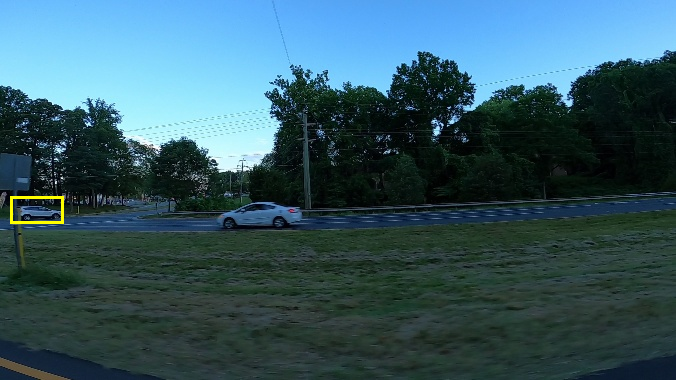

In [5]:
import torchvision
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes

select_row = 500
df_train = pd.read_csv("/content/data/train_solution_bounding_boxes (1).csv")
select = bbox = df_train.iloc[select_row,0]
img = read_image('/content/data/training_images/'+str(select))
bbox = df_train.iloc[select_row,1:5]
bbox = torch.tensor(bbox, dtype=torch.int)
bbox=bbox.unsqueeze(0)
img=draw_bounding_boxes(img, bbox, width=3, colors=(255,255,0))
img = torchvision.transforms.ToPILImage()(img)
img.show()

In [8]:
!mkdir /content/data/train/match_car

for row in df_train.iterrows():
  try:
    img = read_image('/content/data/train/car/'+row[1][0])
  except Exception as e:
    print("Nothing",e)

In [9]:
img

tensor([[[158, 158, 157,  ..., 141, 141, 140],
         [158, 158, 158,  ..., 141, 141, 141],
         [159, 159, 159,  ..., 141, 141, 142],
         ...,
         [ 32,  31,  32,  ...,  29,  29,  30],
         [ 33,  32,  33,  ...,  29,  28,  29],
         [ 33,  32,  33,  ...,  28,  28,  29]],

        [[216, 216, 215,  ..., 198, 198, 197],
         [216, 216, 216,  ..., 198, 198, 198],
         [217, 217, 217,  ..., 198, 198, 199],
         ...,
         [ 44,  43,  44,  ...,  39,  39,  40],
         [ 45,  44,  45,  ...,  41,  40,  41],
         [ 45,  44,  45,  ...,  40,  40,  41]],

        [[253, 253, 252,  ..., 251, 251, 250],
         [253, 253, 253,  ..., 251, 251, 251],
         [254, 254, 254,  ..., 251, 251, 252],
         ...,
         [ 56,  55,  56,  ...,  49,  51,  50],
         [ 57,  56,  57,  ...,  53,  54,  53],
         [ 57,  56,  57,  ...,  54,  54,  55]]], dtype=torch.uint8)

In [20]:
from torchvision import transforms
transform = transforms.Compose([
  transforms.PILToTensor(),
])

train_data = torchvision.datasets.ImageFolder("/content/data/train/", transform = transform)
trainloader = torch.utils.data.DataLoader(train_data, batch_size=4,
                                          shuffle=True, num_workers=2)
trainloader

# def data_generator(df, batch_size=16):
#   while True:
#     for i in range(batch_size):
#       index = np.random.randint(0, len(df_train))
#       row = df_train[index, :]
      

FileNotFoundError: ignored

In [ ]:
train_data

# **Model**

In [48]:
class car_detection(nn.Module):
  def __init__(self)->None:
    super().__init__()
    self.block = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
        nn.MaxPool2d(2,2),
        nn.ReLU(),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
        nn.MaxPool2d(2,2),
        nn.ReLU(),
        nn.Conv2d(in_channels=32, out_channels=1, kernel_size=3, padding=1),
        nn.MaxPool2d(2,2),
        nn.ReLU(),
    )
    self.fully_connective_layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=47*84, out_features=1024),
        nn.ReLU(),
        nn.Linear(in_features=1024, out_features=128),
        nn.ReLU(),
        nn.Linear(in_features=128, out_features=32),
         nn.ReLU(),
        nn.Linear(in_features=32, out_features=4),
    )
  def forward(self, X):
    X = self.block(X)
    X = self.fully_connective_layer(X)
    return X

model = car_detection()


In [13]:
import torch
from PIL import Image
import torchvision.transforms as transforms
  

df_train = pd.read_csv("/content/data/train_solution_bounding_boxes (1).csv")
select = df_train.iloc[select_row,0]
image = Image.open('/content/data/training_images/'+str(select))

transform = transforms.Compose([
    transforms.PILToTensor()
])
  
img_tensor = transform(image).to(torch.float32)
sampel_pred = model(img_tensor)

FileNotFoundError: ignored

# **IoU**

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# return IOU= area of intersection / area of union
def IoU (box_preds, box_labels):
  box1_left = box_preds[...,0:1]
  box1_up = box_preds[...,1:2]
  box1_right = box_preds[...,2:3]
  box1_low = box_preds[...,3:4]
  box2_left = box_labels[...,0:1]
  box2_up = box_labels[...,1:2]
  box2_right = box_labels[...,2:3]
  box2_low = box_labels[...,3:4]

  box_right = torch.min(box1_right, box2_right)
  box_left = torch.max(box1_left, box2_left)
  box_low = torch.min(box1_low, box2_low)
  box_up = torch.max(box1_up, box2_up)
  intersection_area = (box_right-box_left).clamp(0)*(box_low-box_up).clamp(0)
  union_area = abs((box1_right-box1_left)*(box1_low-box1_up))+abs((box2_right-box2_left)*(box2_low-box2_up))-intersection_area+1e-6
  return intersection_area/union_area

# **Training and Evaluation**

In [ ]:
IoU(y_pred,y_lable)

In [49]:
from torchvision import transforms

epochs =  10
BATCH_SIZE = 16
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

for epoch in range(epochs):
  model.train()
  select_index = np.random.randint(0,len(df_train), size=BATCH_SIZE)
  batch = df_train.iloc[select_index]
  loss = 0
  for batch_index in batch.iterrows():
    img = Image.open('/content/data/training_images/'+str(batch_index[1][0]))
    img = transform(img).to(torch.float32)
    y_pred = model(img)
    y_pred = y_pred.squeeze(0)
    y_label = torch.tensor(batch_index[1][1:])
    print(y_pred,y_label)
    loss += loss_fn(y_pred, y_label)
    print(loss)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  print(loss)


tensor([-0.3388, -0.0801,  0.1750, -0.0741], grad_fn=<SqueezeBackward1>) tensor([595.2909, 180.1882, 650.5644, 215.4006])
tensor(214176.7500, grad_fn=<AddBackward0>)
tensor([2.4398e+10, 7.8378e+09, 2.6944e+10, 9.5058e+09],
       grad_fn=<SqueezeBackward1>) tensor([492.5702, 183.1226, 624.1505, 220.7802])
tensor(3.6825e+20, grad_fn=<AddBackward0>)


RuntimeError: ignored

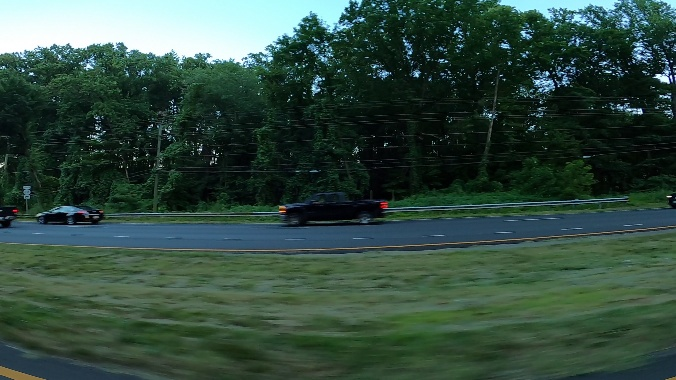

In [34]:
import torchvision
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes

select_index = np.random.randint(0,len(df_train))
select = df_train.iloc[select_index,0]
img_pil = Image.open('/content/data/training_images/'+str(select))
img_un = read_image('/content/data/training_images/'+str(select))
bbox = df_train.iloc[select_row,1:5]
img_tensor = transform(img).to(torch.float32)
bbox = model(img_tensor)
# bbox = torch.tensor(bbox, dtype=torch.int)
# bbox = bbox.unsqueeze(0)
img= draw_bounding_boxes(img_un, bbox, width=3, colors=(255,255,0))
img = torchvision.transforms.ToPILImage()(img)
img.show()




tensor([[-inf, -inf, -inf, -inf]], grad_fn=<AddmmBackward0>)